IGU MYO YZ DERSİ 30.09.2024 - DERS NOTU
FURKAN YAŞAR

In [ ]:
print("Merhaba IGU MYO YZ") # İlk python programı çıktısı

Merhaba IGU MYO YZ


In [ ]:
import sys #import python programlama dilinde yazılıma kütüphane eklemeye yarayan bir kod bloğudur
print(sys.version)

3.10.12 (main, Sep 11 2024, 15:47:36) [GCC 11.4.0]


In [ ]:
from google.colab import drive #google colab - drive bağlantısı

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

os.chdir('/content/drive/My Drive/YZIGU')

!pwd # bize kodun çıktısını dosya yolu olarak veren kod blogudur

/content/drive/My Drive/YZIGU


In [ ]:
# cpu ve gpu teknolojisinin kullanımına göre olması gereken veriler

import pandas as pd

tablo = {
    "Aralık":["Küçük ölçekli", "Orta ölçekli", "Büyük ölçekli", "Hiper ölçekli", "Excale"],
    "Veri Sayısı":["100 - 10,000", "10.000 - 100,000","100,000 - Milyon","Milyon - Milyar", "Milyar - Trilyon"],
    "CPU":["Evet","Evet","Opsiyonel","Hayır","Hayır"],
    "GPU": ["Hayır", "Opsiyonel", "Evet", "Evet", "Evet"]
}

print(pd.DataFrame(tablo))

          Aralık       Veri Sayısı        CPU        GPU
0  Küçük ölçekli      100 - 10,000       Evet      Hayır
1   Orta ölçekli  10.000 - 100,000       Evet  Opsiyonel
2  Büyük ölçekli  100,000 - Milyon  Opsiyonel       Evet
3  Hiper ölçekli   Milyon - Milyar      Hayır       Evet
4         Excale  Milyar - Trilyon      Hayır       Evet


In [ ]:
import pandas as pd

# True Positive (TP), True Negative (TN), False Positive (FP), False Negative (FN)
matris_bilgisi = {
    "Gerçek Pozitif": ["Doğru Pozitif (TP)", "Yanlış Negatif (FN)"],
    "Gerçek Negatif": ["Yanlış Pozitif (FP)", "Doğru Negatif (TN)"]
}

# DataFrame oluşturma
matris = pd.DataFrame(matris_bilgisi, index=["Tahmin Pozitif", "Tahmin Negatif"])

# Tabloyu gösterme
print(matris)

                     Gerçek Pozitif       Gerçek Negatif
Tahmin Pozitif   Doğru Pozitif (TP)  Yanlış Pozitif (FP)
Tahmin Negatif  Yanlış Negatif (FN)   Doğru Negatif (TN)


In [ ]:
# Scikit-Learn kütüphanesinin sisteme dahil edilmesi ve veri setinin işleme alınması
#bir makine öğrenimi kütüphanesidir

!pip install -U Scikit-learn

In [ ]:
#datasets california konut verilerini yükler ve fch : fonkunu içe aktarır
from sklearn.datasets import fetch_california_housing
import pandas as pd

# California Housing veri setini yükleme
housing = fetch_california_housing()

# Özellikleri ve hedef değişkeni almak
x = housing.data  # Bağımsız değişkenler (özellikler)
y = housing.target  # Bağımlı değişken (fiyatlar)

# Verileri bir DataFrame'e dönüştürme
df = pd.DataFrame(x, columns=housing.feature_names)
#dataframeye yeni bir sütun olarak ekler
df['PRICE'] = y

# İlk beş satırı görüntüleme
print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [ ]:
from sklearn.datasets import fetch_california_housing
#Veri setini eğitim ve test setlerine ayırmak için kullanılır.
from sklearn.model_selection import train_test_split
#Doğrusal regresyon modelini oluşturmak için kullanılır.
from sklearn.linear_model import LinearRegression
#Modelin performansını değerlendirmek için kullanılan metriklerdir.
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# California Housing veri setini yükleme
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
#sütunu, konut fiyatlarını temsil eder
df['PRICE'] = housing.target

# Özellikler ve hedef değişkeni ayırma
X = df.drop('PRICE', axis=1)
y = df['PRICE']

# train_test_split: Veri setini eğitim ve test setlerine ayırır.
#test_size=0.3 ifadesi, verilerin %30'unun test seti olarak ayrılacağını belirtir.
#random_state=42 ise sonuçların tekrarlanabilir olmasını sağlar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model oluşturma
#Doğrusal regresyon modelini oluşturur.
model = LinearRegression()
#Model, eğitim verileri ile eğitilir.
model.fit(X_train, y_train)

# Tahmin yapma
#Test seti için tahminler yapar.
#İlk beş tahmin ve gerçek değerler ekrana yazdırılır.
predictions = model.predict(X_test)
print("Tahmin Sonucları: ", predictions[:5])
print("Gerçek Değerler: ", y_test[:5].values)

# Sistemin Ortalama Hatası (MSE)
#(y_test) ile modelin tahmin ettiği değerler (predictions) arasındaki ortalama kare hatayı hesaplar.
#MSE'nin değeri ne kadar düşükse, modelin tahminleri o kadar iyidir.
#Ancak, MSE'nin birimlerinin karesi olduğu için, yorumlanması zor olabilir.
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error (MSE) Sonucu:", mse)

# Sistemin R-kare Hatası (R²)
r2 = r2_score(y_test, predictions)
print("R-squared (R²) Sonucu:", r2)

Tahmin Sonucları:  [0.72604907 1.76743383 2.71092161 2.83514727 2.60695807]
Gerçek Değerler:  [0.477   0.458   5.00001 2.186   2.78   ]
Mean Squared Error (MSE) Sonucu: 0.5305677824766758
R-squared (R²) Sonucu: 0.595770232606166


In [ ]:
# TensorFlow kütüphanesinin sisteme dahil edilmesi ve veri setinin işleme alınması

#Graphviz ile etkileşimde bulunmak için kullanılan bir kütüphanedir. grafik oluşturma vb.
#makine öğrenimini görselleştirmek için
!pip install pydot
#graphviz yzılımını yükler
!apt-get install graphviz

# Bu iki kütüphane ile oluşturulan yapay zeka modelinin yapısını çıktı alabileceğiz.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


In [ ]:
#derin öğrenme ve makine öğrenimi uygulamaları
import tensorflow as tf
#Keras, TensorFlow'un üstünde çalışan bir yüksek seviyeli API'dir ve model oluşturmayı kolaylaştırır.
from tensorflow.keras import layers, models
#MNIST, el yazısı rakamlarının görüntülerini içeren bir veri setidir.
from tensorflow.keras.datasets import mnist
#Modelin mimarisini görselleştirmek için kullanılan bir yardımcı fonksiyonu içe aktarır.
from tensorflow.keras.utils import plot_model

(x_train, y_train), (x_test, y_test) = mnist.load_data() # MNIST veri setini yükleme
x_train, x_test = x_train / 255.0, x_test / 255.0
!pwd

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
/content/drive/MyDrive/YZIGU


In [ ]:
#Keras'ta katmanları sıralı bir şekilde eklemek için kullanılan bir model türüdür.
#Bu model, katmanların bir sırayla birbirine bağlandığı basit bir yapıdır.
model = models.Sequential([ # Modeli oluşturma
    #Bu katman, 2D görüntüleri (28x28 piksel) 1D bir vektöre dönüştürür.
    layers.Flatten(input_shape=(28, 28)),
    #128 nörondan oluşur, relu negatifi 0 yapar pozitife dokunmaz
    layers.Dense(128, activation='relu'),
    #%20 oranında nöronları kapatır
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#compile modelin eğitiminde kullanılır
#adam modelin daha hızlı ve etkili öğrenmesini sağlar öğrenme oranı otodur en yaygını
model.compile (optimizer='adam', # Modeli derleme
              #çok sınıflı sınıflandırma problemleri için uygun bir kayıp fonksiyonudur.
              loss='sparse_categorical_crossentropy',
              #performansını belirleyecek metricsi belirler
              #accuracy doğru tahmin,n toplam tahmine oranını ölçer
              metrics=['accuracy'])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8594 - loss: 0.4812
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9536 - loss: 0.1556
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9671 - loss: 0.1089
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9737 - loss: 0.0872
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9769 - loss: 0.0727


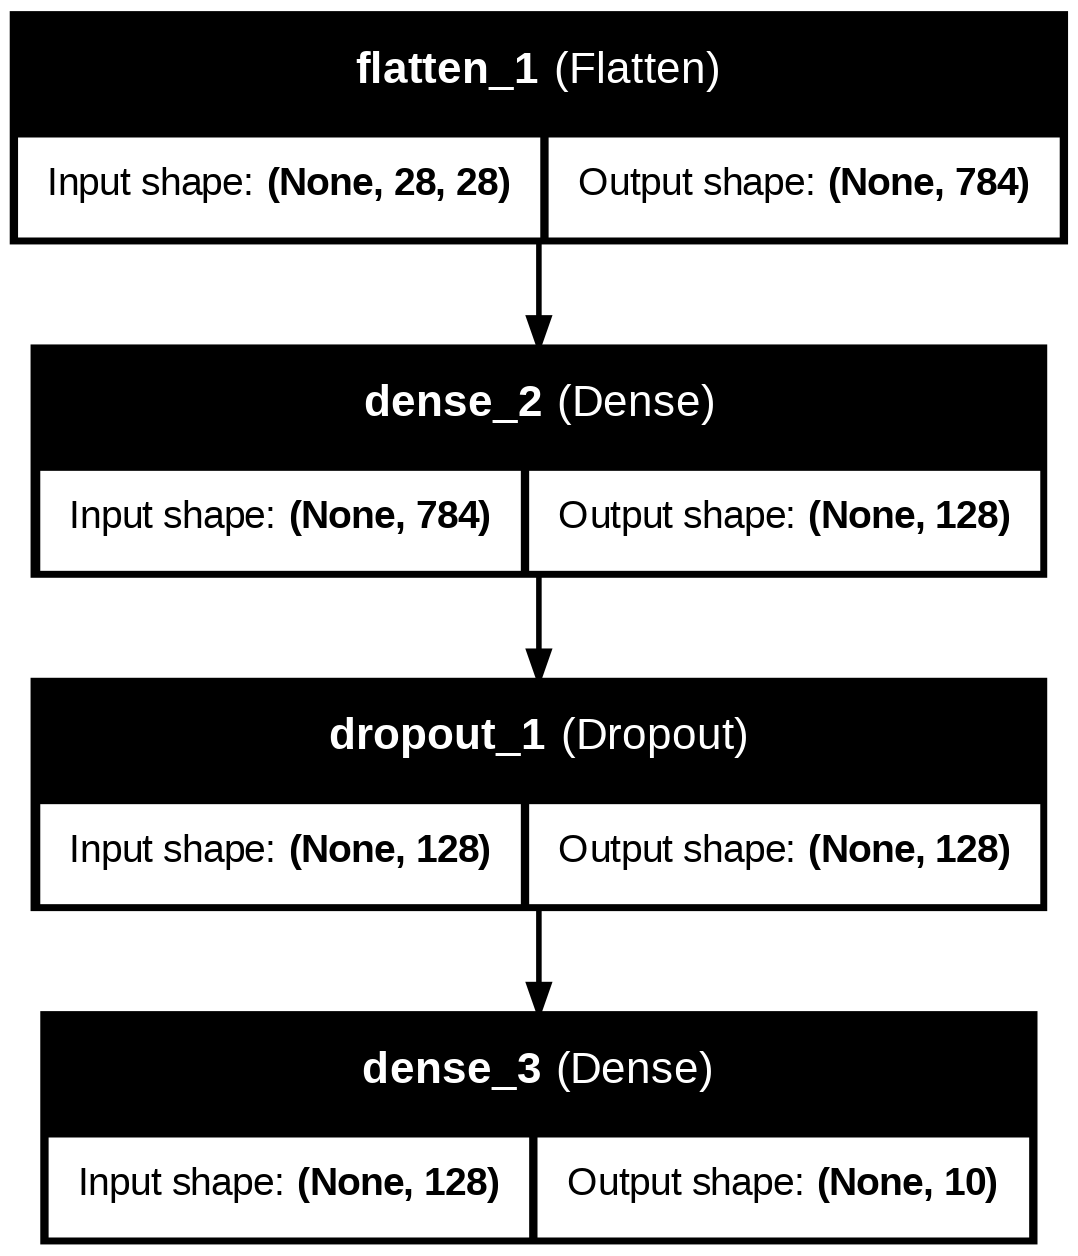

In [ ]:
#modelin eğitilmesini sağlar x=eğitim verileri y=eğitim etiketleri e=eğitim verilerini kaç kez alıcağı
model.fit(x_train, y_train, epochs=5) # Modeli Eğitilmesi Adımı

# Modeli görselleştirmek ve çalışma alanına kaydetmek için plot_model kullanımı
plot_model(model, to_file='YZ_Model/yz_tensoflow_model_ciktisi.png', show_shapes=True, show_layer_names=True) # Modelin Çıktısı


In [ ]:
# Test seti üzerinde modelin performansını değerlendirme

#test üzerindeki performansı belirler ver= ayrıntılı bir şekilde veri gösterimi
hata_oranı, basarı_oranı = model.evaluate(x_test, y_test, verbose=2)

print(" Modelin Doğruluk Oranı: %", basarı_oranı*100)
print(" Modelin Hata Oranı: %", hata_oranı*100)

313/313 - 1s - 2ms/step - accuracy: 0.9781 - loss: 0.0678
 Modelin Doğruluk Oranı: % 97.81000018119812
 Modelin Hata Oranı: % 6.778974831104279


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 527kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.33MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch 1, Loss: 0.7513411891485836, Accuracy: 81.825%
Epoch 2, Loss: 0.3688910804561842, Accuracy: 89.47666666666667%
Epoch 3, Loss: 0.3246473204225365, Accuracy: 90.58833333333334%
Epoch 4, Loss: 0.30004384985038723, Accuracy: 91.26833333333333%
Epoch 5, Loss: 0.28000530508408417, Accuracy: 91.90333333333334%
Epoch 6, Loss: 0.2620019214366799, Accuracy: 92.44833333333334%
Epoch 7, Loss: 0.24419537000358105, Accuracy: 92.95166666666667%
Epoch 8, Loss: 0.22783729290244167, Accuracy: 93.505%
Epoch 9, Loss: 0.21213138774275653, Accuracy: 93.99166666666666%
Epoch 10, Loss: 0.19779915436864026, Accuracy: 94.48166666666667%
Epoch 11, Loss: 0.1852489169567887, Accuracy: 94.77333333333333%
Epoch 12, Loss: 0.17367031694109888, Accuracy: 95.06%
Epoch 13, Loss: 0.16369936449218914, Accuracy: 95.38333333333334%
Epoch 14, Loss: 0.15504649390122974, Accuracy: 95.63833333333334%
Epoch 15, Loss: 0.14657563330140957, Accuracy: 95

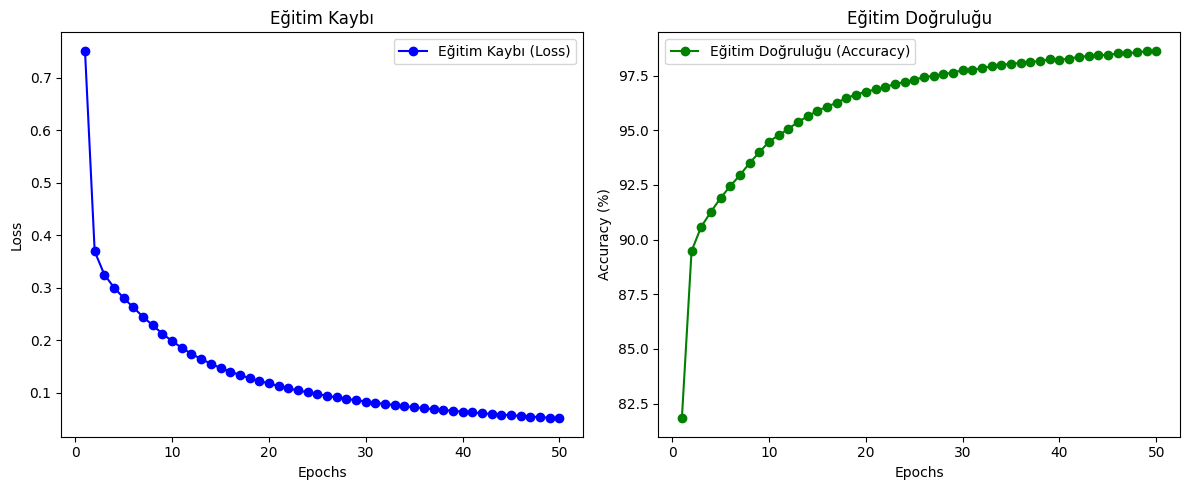

In [ ]:
import torch
import torch.nn as nn #Sinir ağı katmanları ve fonksiyonları için.
import torch.optim as optim #Optimizasyon algoritmaları için.
from torchvision import datasets, transforms #Görüntü işleme ve veri setleri için.
import matplotlib.pyplot as plt

# MNIST veri setini yükleme
#Görüntüleri tensörlere dönüştürmek ve normalleştirmek için bir dizi dönüşüm tanımlar.
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
#MNIST veri setini yükler. train=True ile eğitim setini, train=False ile test setini alır.
train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST('./data', train=False, transform=transform)

#Eğitim ve test verilerini yüklemek için kullanılır. batch_size=64 ile her seferinde 64 görüntü yüklenir.
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

# Modeli oluşturma
#Net = Sinir ağı modelini tanımlayan bir sınıf. İki tam bağlantılı katman (fully connected layer) içerir
#forward: Modelin ileri yayılımını tanımlar.
# iki katman arasında ReLU aktivasyon fonksiyonu uygulanır.
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()

# Kayıp fonksiyonu ve optimizer
#criterion: Kayıp fonksiyonu olarak çapraz entropi kaybı kullanılır.
criterion = nn.CrossEntropyLoss()
#optimizer: Stokastik gradyan inişi (SGD) optimizasyon algoritması ile modelin parametreleri güncellenir.
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Eğitim için boş listeler tanımla
train_losses = []
train_accuracies = []

# Eğitme döngüsü
for epoch in range(50):  # 50 epoch boyunca eğit
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        # Kayıp (loss) değerini topla
        running_loss += loss.item()

        # Doğruluğu hesapla
        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Her epoch sonunda ortalama kayıp ve doğruluk
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f'Epoch {epoch+1}, Loss: {epoch_loss}, Accuracy: {epoch_accuracy}%')

print('Eğitim tamamlandı!')

# Eğitim sonuçlarını grafikle göster
epochs = range(1, 51)  # 50 epoch olduğu için 1'den 51'ya kadar olan epoch'lar
#figür oluşturur
plt.figure(figsize=(12, 5))

# Kayıp grafiği
plt.subplot(1, 2, 1)
#Kayıp değerlerini (train_losses) mavi noktalarla ('bo-') çizer.
plt.plot(epochs, train_losses, 'bo-', label='Eğitim Kaybı (Loss)')
plt.title('Eğitim Kaybı')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Doğruluk grafiği
plt.subplot(1, 2, 2)
#Doğruluk değerlerini (train_accuracies) yeşil noktalarla ('go-') çizer.
plt.plot(epochs, train_accuracies, 'go-', label='Eğitim Doğruluğu (Accuracy)')
plt.title('Eğitim Doğruluğu')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

#Alt grafiklerin düzenini otomatik olarak ayarlar, böylece etiketler ve başlıklar çakışmaz.
plt.tight_layout()
plt.show()

In [ ]:
# Test verisi üzerinde modelin performansını değerlendirme
test_loss = 0.0 #Test verisi üzerindeki toplam kaybı tutmak için başlatılır.
correct = 0 # Doğru tahmin edilen örneklerin sayısını tutar.
total = 0 #Toplam örnek sayısını tutar.

# Test verisi üzerinde modelin kaybını ve doğruluğunu hesapla (gradyan hesaplama yok)
with torch.no_grad(): # gradyan hesaplamalarını devre dışı bırakır
    for images, labels in test_loader: #Test verilerini yükler
        output = model(images)
        loss = criterion(output, labels) #Tahmin edilen çıktılar ile gerçek etiketler arasındaki kaybı hesaplar.
        test_loss += loss.item()

        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Test seti kaybı ve doğruluğu
test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print("Test Seti Kaybı: ", test_loss)
print("Test Seti Doğruluğu: ", test_accuracy , "%")

Test Seti Kaybı:  0.07849950935753881
Test Seti Doğruluğu:  97.7 %


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# MNIST veri setini yükleme
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Giriş verisini normalize etme ve düzleştirme
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28*28).astype('float32') / 255.0

# Çıkış verisini kategorik hale getirme
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Modeli oluşturma
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(28*28,)))
model.add(Dense(10, activation='softmax'))

# Modeli derleme
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Modeli eğitme
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8790 - loss: 0.4306 - val_accuracy: 0.9599 - val_loss: 0.1339
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9644 - loss: 0.1228 - val_accuracy: 0.9723 - val_loss: 0.0950
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9767 - loss: 0.0754 - val_accuracy: 0.9753 - val_loss: 0.0810
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9825 - loss: 0.0576 - val_accuracy: 0.9764 - val_loss: 0.0775
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9864 - loss: 0.0441 - val_accuracy: 0.9760 - val_loss: 0.0738
